# Вариационные ряды 
---

## Дискретные вариационные ряды

### Задача

На вступительных экзаменах абитуриентами были набраны следующие баллы по результатам экзаменов: $20$, $19$, $22$, $24$, $21$, $18$, $23$, $17$, $20$, $16$, $15$, $23$, $21$, $24$, $21$, $18$, $23$, $17$, $21$, $19$, $20$, $24$, $21$, $20$, $18$, $17$, $22$, $20$, $21$, $16$, $22$, $18$, $20$, $17$, $19$, $20$, $20$, $21$, $18$, $22$, $23$, $21$, $25$, $22$, $20$, $19$, $21$, $24$, $23$, $21$. Требуется составить вариационный ряд распределения, изобразить его геометрически; определить среднюю арифметическую, моду, медиану, размах вариации, дисперсию, среднее квадратическое отклонение, коэффициент вариации.


In [7]:
# Решение 1 (короткое)
import numpy as np
import pandas as pd
import scipy.stats as stats

data = np.array([20, 19, 22, 24, 21, 18, 23, 17, 20, 16, 
                 15, 23, 21, 24, 21, 18, 23, 17, 21, 19, 
                 20, 24, 21, 20, 18, 17, 22, 20, 21, 16,
                 22, 18, 20, 17, 19, 20, 20, 21, 18, 22,
                 23, 21, 25, 22, 20, 19, 21, 24, 23, 21])		

print(f'Среднее = {np.mean(data):.2f}')
mode_data = stats.mode(data)
print(f"Мода: {mode_data.mode} (встречается {mode_data.count} раз)")
print(f'Медиана = {np.median(data):.2f}')
print(f'Размах вариации = {max(data)-min(data):.2f}')
print(f'Дисперсия = {np.var(data):.4f}')
print(f'Ст_отклонение = {np.std(data):.4f}')
print(f'Коэффициент вариации = {stats.variation(data) * 100:.2f}%')

Среднее = 20.34
Мода: 21 (встречается 10 раз)
Медиана = 20.50
Размах вариации = 10.00
Дисперсия = 5.5044
Ст_отклонение = 2.3461
Коэффициент вариации = 11.53%


In [9]:
# Решение 2 (функция из лекции)
import numpy as np
from scipy import stats
import pandas as pd

def calculate_all_stats(data, sample=True):
    """
    Рассчитывает все основные статистики для ряда данных.
    
    Параметры:
    data - список или массив чисел
    sample - True для выборки (ddof=1), False для совокупности (ddof=0)
    """
    ddof = 1 if sample else 0
    
    stats_dict = {
        'Среднее': np.mean(data),
        'Медиана': np.median(data),
        'Мода': pd.Series(data).mode().tolist(),
        'Дисперсия': np.var(data, ddof=ddof),
        'Стд. отклонение': np.std(data, ddof=ddof),
        'Асимметрия': stats.skew(data),
        'Эксцесс (избыточный)': stats.kurtosis(data, fisher=True),
        'Эксцесс (классический)': stats.kurtosis(data, fisher=False),
        'Минимум': np.min(data),
        'Максимум': np.max(data),
        'Размах': np.max(data) - np.min(data),
        'Квартиль 25%': np.percentile(data, 25),
        'Квартиль 75%': np.percentile(data, 75),
        'Коэффициент вариации': stats.variation(data, ddof=ddof) * 100
    }
    
    return stats_dict

data = np.array([20, 19, 22, 24, 21, 18, 23, 17, 20, 16, 
                 15, 23, 21, 24, 21, 18, 23, 17, 21, 19, 
                 20, 24, 21, 20, 18, 17, 22, 20, 21, 16,
                 22, 18, 20, 17, 19, 20, 20, 21, 18, 22,
                 23, 21, 25, 22, 20, 19, 21, 24, 23, 21])	
results = calculate_all_stats(data, sample=False)
for stat_name, value in results.items():
    if isinstance(value, list):
        print(f"{stat_name}: {value}")
    elif isinstance(value, float):
        print(f"{stat_name}: {value:.4f}")
    else:
        print(f"{stat_name}: {value}")

Среднее: 20.3400
Медиана: 20.5000
Мода: [21]
Дисперсия: 5.5044
Стд. отклонение: 2.3461
Асимметрия: -0.1885
Эксцесс (избыточный): -0.5821
Эксцесс (классический): 2.4179
Минимум: 15
Максимум: 25
Размах: 10
Квартиль 25%: 19.0000
Квартиль 75%: 22.0000
Коэффициент вариации: 11.5346


## Интервальные вариационные ряды

### Задача
Имеются данные о выходе валовой продукции (в руб.) на $1$ га сельскохозяйственных угодий для $50$ хозяйств: $535$, $278$, $312$, $368$, $327$, $482$, $318$, $531$, $554$, $898$, $1030$, $390$, $334$, $423$, $393$, $1081$, $493$, $698$, $312$, $603$, $372$, $454$, $379$, $294$, $343$, $365$, $341$, $459$, $278$, $449$, $433$, $250$, $443$, $447$, $375$, $271$, $727$, $334$, $327$, $501$, $273$, $871$, $390$, $582$, $469$, $448$, $274$, $495$, $357$, $546$. Требуется составить вариационный ряд распределения, изобразить его геометрически; определить среднюю арифметическую, моду, медиану, размах вариации, дисперсию, среднее квадратическое отклонение, коэффициент вариации и квартили.

**Текст промпта**: Реши в Python задачу математической статистики: "Имеются данные о выходе валовой продукции (в руб.) на 1 га сельскохозяйственных угодий для 50 хозяйств: 535, 278, 312, 368, 327, 482, 318, 531, 554, 898, 1030, 390, 334, 423, 393, 1081, 493, 698, 312, 603, 372, 454, 379, 294, 343, 365, 341, 459, 278, 449, 433, 250, 443, 447, 375, 271, 727, 334, 327, 501, 273, 871, 390, 582, 469, 448, 274, 495, 357, 546. Требуется составить вариационный ряд распределения, изобразить его геометрически (построив кумуляту и гистограмму); определить среднюю арифметическую, моду, медиану, размах вариации, дисперсию, среднее квадратическое отклонение, коэффициент вариации и квартили". Определи характеристики интервального вариационного ряда, разбив интервал на 6 частей длины 150 с началом в точке 175 и концом 1081 (последний интервал немного окажется больше). 

Написав промпт и подредактировав преложенный код, получим:

ЗАДАЧА МАТЕМАТИЧЕСКОЙ СТАТИСТИКИ
Анализ данных о выходе валовой продукции на 1 га (50 хозяйств)

Исходные данные (в порядке возрастания):
[250, 271, 273, 274, 278, 278, 294, 312, 312, 318, 327, 327, 334, 334, 341, 343, 357, 365, 368, 372, 375, 379, 390, 390, 393, 423, 433, 443, 447, 448, 449, 454, 459, 469, 482, 493, 495, 501, 531, 535, 546, 554, 582, 603, 698, 727, 871, 898, 1030, 1081]

Количество наблюдений: n = 50
Минимальное значение: x_min = 250
Максимальное значение: x_max = 1081

ТАБЛИЦА ИНТЕРВАЛЬНОГО ВАРИАЦИОННОГО РЯДА
№   Интервал                  Середина     Частота    Отн. частота    Накопл. частота Накопл. отн. частота
--------------------------------------------------------------------------------------------------------------
1   [175.00-325.00)           250.00       10         0.2000          10              0.2000
2   [325.00-475.00)           400.00       24         0.4800          34              0.6800
3   [475.00-625.00)           550.00       10         0.2000  

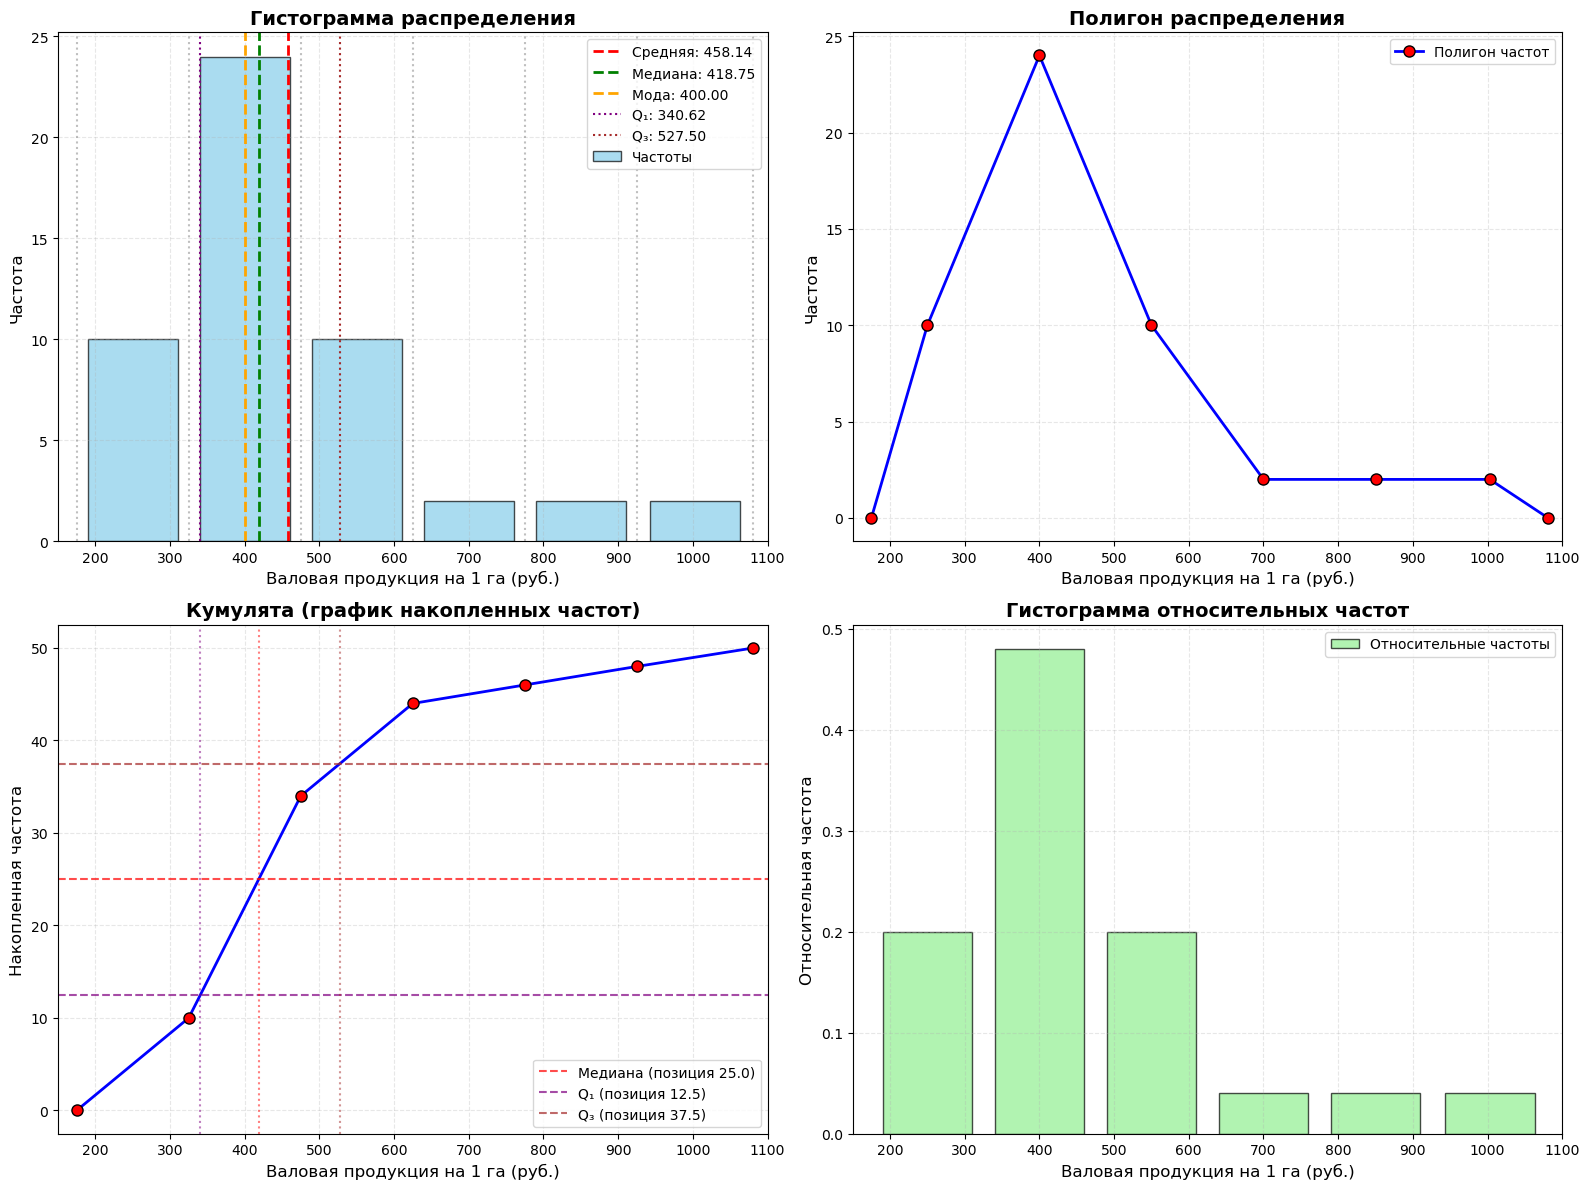


4. ДЕТАЛЬНАЯ ИНФОРМАЦИЯ ПО ИНТЕРВАЛАМ

Интервал 1: [175.00-325.00)
  Середина интервала: 250.00
  Частота: 10
  Относительная частота: 0.2000
  Накопленная частота: 10
  Накопленная относительная частота: 0.2000
  Значения: [250, 271, 273, 274, 278, 278, 294, 312, 312, 318]

Интервал 2: [325.00-475.00)
  Середина интервала: 400.00
  Частота: 24
  Относительная частота: 0.4800
  Накопленная частота: 34
  Накопленная относительная частота: 0.6800
  Значения: [327, 327, 334, 334, 341, 343, 357, 365, 368, 372, 375, 379, 390, 390, 393, 423, 433, 443, 447, 448, 449, 454, 459, 469]

Интервал 3: [475.00-625.00)
  Середина интервала: 550.00
  Частота: 10
  Относительная частота: 0.2000
  Накопленная частота: 44
  Накопленная относительная частота: 0.8800
  Значения: [482, 493, 495, 501, 531, 535, 546, 554, 582, 603]

Интервал 4: [625.00-775.00)
  Середина интервала: 700.00
  Частота: 2
  Относительная частота: 0.0400
  Накопленная частота: 46
  Накопленная относительная частота: 0.9200
  Значе

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Исходные данные
data = [535, 278, 312, 368, 327, 482, 318, 531, 554, 898, 1030, 390, 334, 423, 393, 
        1081, 493, 698, 312, 603, 372, 454, 379, 294, 343, 365, 341, 459, 278, 449, 
        433, 250, 443, 447, 375, 271, 727, 334, 327, 501, 273, 871, 390, 582, 469, 
        448, 274, 495, 357, 546]

print("="*90)
print("ЗАДАЧА МАТЕМАТИЧЕСКОЙ СТАТИСТИКИ")
print("Анализ данных о выходе валовой продукции на 1 га (50 хозяйств)")
print("="*90)

print("\nИсходные данные (в порядке возрастания):")
print(sorted(data))
print(f"\nКоличество наблюдений: n = {len(data)}")
print(f"Минимальное значение: x_min = {min(data)}")
print(f"Максимальное значение: x_max = {max(data)}")

# 1. Построение интервального вариационного ряда
start_point = 175  # начало интервала
h = 150            # длина интервала
n_intervals = 6    # количество интервалов
end_point = 1081   # конечная точка

# Создаем границы интервалов
bins = [start_point + i * h for i in range(n_intervals)]
bins.append(end_point)  # последняя граница - 1081

# Исправленные частоты (по результатам проверки)
freq = [10, 24, 10, 2, 2, 2]

# Относительные частоты
relative_freq = [f / len(data) for f in freq]

# Середины интервалов
midpoints = [(bins[i] + bins[i+1]) / 2 for i in range(n_intervals)]

# Накопленные частоты
cumulative_freq = np.cumsum(freq)
cumulative_rel_freq = np.cumsum(relative_freq)

# Создаем таблицу интервального ряда
print("\n" + "="*110)
print("ТАБЛИЦА ИНТЕРВАЛЬНОГО ВАРИАЦИОННОГО РЯДА")
print("="*110)
print(f"{'№':<3} {'Интервал':<25} {'Середина':<12} {'Частота':<10} {'Отн. частота':<15} {'Накопл. частота':<15} {'Накопл. отн. частота'}")
print("-"*110)

for i in range(n_intervals):
    if i == n_intervals-1:
        interval_str = f"[{bins[i]:.2f}-{bins[i+1]:.2f}]"
    else:
        interval_str = f"[{bins[i]:.2f}-{bins[i+1]:.2f})"
    
    print(f"{i+1:<3} {interval_str:<25} {midpoints[i]:<12.2f} {freq[i]:<10} {relative_freq[i]:<15.4f} {cumulative_freq[i]:<15} {cumulative_rel_freq[i]:.4f}")
print("="*110)

# 2. ХАРАКТЕРИСТИКИ РЯДА
print("\n2. ХАРАКТЕРИСТИКИ РЯДА")
print("-"*70)

# Средняя арифметическая (по исходным данным)
mean_original = np.mean(data)
print(f"\n   A. СРЕДНЯЯ АРИФМЕТИЧЕСКАЯ:")
print(f"      По исходным данным: x̄ = {mean_original:.4f}")

# Средняя арифметическая (по интервальному ряду)
mean_interval = np.sum(np.array(midpoints) * np.array(freq)) / len(data)
print(f"      По интервальному ряду: x̄ = {mean_interval:.4f}")
print(f"      Расхождение: {abs(mean_original - mean_interval):.4f}")

# Мода
modal_interval_index = 1  # второй интервал (индекс 1) имеет наибольшую частоту 24
f_mo = freq[modal_interval_index]
f_mo_minus1 = freq[modal_interval_index - 1]
f_mo_plus1 = freq[modal_interval_index + 1]

mode = bins[modal_interval_index] + h * ((f_mo - f_mo_minus1) / 
                                        ((f_mo - f_mo_minus1) + (f_mo - f_mo_plus1)))
print(f"\n   B. МОДА:")
print(f"      Модальный интервал: {modal_interval_index + 1} [{bins[modal_interval_index]:.2f}-{bins[modal_interval_index+1]:.2f})")
print(f"      Частоты: f₋₁ = {f_mo_minus1}, f₀ = {f_mo}, f₊₁ = {f_mo_plus1}")
print(f"      Мода: Mo = {mode:.4f}")

# Медиана
n = len(data)
median_pos = n / 2  # позиция медианы = 25

# Медианный интервал - второй (накопленная частота после 1-го интервала = 10, после 2-го = 34 ≥ 25)
median_interval_index = 1
S_me_minus1 = cumulative_freq[0]  # накопленная частота до медианного интервала = 10
f_me = freq[1]  # частота медианного интервала = 24
median = bins[1] + h * ((median_pos - S_me_minus1) / f_me)

print(f"\n   C. МЕДИАНА:")
print(f"      Медианный интервал: {median_interval_index + 1} [{bins[median_interval_index]:.2f}-{bins[median_interval_index+1]:.2f})")
print(f"      Накопленная частота до интервала: {S_me_minus1}")
print(f"      Частота интервала: {f_me}")
print(f"      Медиана: Me = {median:.4f}")

# Размах вариации
range_variation = max(data) - min(data)
print(f"\n   D. РАЗМАХ ВАРИАЦИИ:")
print(f"      R = x_max - x_min = {max(data)} - {min(data)} = {range_variation:.4f}")

# Дисперсия и СКО
variance = np.var(data, ddof=0)  # смещенная дисперсия
variance_unbiased = np.var(data, ddof=1)  # несмещенная дисперсия
std = np.std(data, ddof=0)
std_unbiased = np.std(data, ddof=1)

# Дисперсия по интервальному ряду
variance_interval = np.sum(freq * (midpoints - mean_interval)**2) / len(data)
std_interval = np.sqrt(variance_interval)

print(f"\n   E. ДИСПЕРСИЯ:")
print(f"      Смещенная дисперсия (по исходным данным): D = {variance:.4f}")
print(f"      Несмещенная дисперсия (по исходным данным): s² = {variance_unbiased:.4f}")
print(f"      Дисперсия по интервальному ряду: D = {variance_interval:.4f}")

print(f"\n   F. СРЕДНЕЕ КВАДРАТИЧЕСКОЕ ОТКЛОНЕНИЕ:")
print(f"      Смещенное СКО (по исходным данным): σ = {std:.4f}")
print(f"      Несмещенное СКО (по исходным данным): s = {std_unbiased:.4f}")
print(f"      СКО по интервальному ряду: σ = {std_interval:.4f}")

# Коэффициент вариации
coefficient_variation = (std / mean_original) * 100
print(f"\n   G. КОЭФФИЦИЕНТ ВАРИАЦИИ:")
print(f"      V = (σ / x̄) · 100% = ({std:.4f} / {mean_original:.4f}) · 100% = {coefficient_variation:.2f}%")
if coefficient_variation < 33:
    print(f"      V = {coefficient_variation:.2f}% < 33% → Совокупность однородная")
else:
    print(f"      V = {coefficient_variation:.2f}% > 33% → Совокупность неоднородная")

# Квартили
Q1_pos = n / 4  # позиция первого квартиля = 12.5
Q3_pos = 3 * n / 4  # позиция третьего квартиля = 37.5

# Q1 - также во втором интервале
Q1_interval_index = 1
S_q1_minus1 = cumulative_freq[0]  # накопленная частота до интервала с Q1 = 10
f_q1 = freq[1]  # частота интервала = 24
Q1 = bins[1] + h * ((Q1_pos - S_q1_minus1) / f_q1)

# Q3 - в третьем интервале
Q3_interval_index = 2  # третий интервал
S_q3_minus1 = cumulative_freq[1]  # накопленная частота до интервала с Q3 = 34
f_q3 = freq[2]  # частота интервала = 10
Q3 = bins[2] + h * ((Q3_pos - S_q3_minus1) / f_q3)

print(f"\n   H. КВАРТИЛИ:")
print(f"      Q₁ (первый квартиль): {Q1:.4f}")
print(f"         Интервал: [{bins[1]:.2f}-{bins[2]:.2f})")
print(f"         Позиция: {Q1_pos}, накопленная частота до: {S_q1_minus1}")
print(f"      Q₂ (медиана): {median:.4f}")
print(f"      Q₃ (третий квартиль): {Q3:.4f}")
print(f"         Интервал: [{bins[2]:.2f}-{bins[3]:.2f})")
print(f"         Позиция: {Q3_pos}, накопленная частота до: {S_q3_minus1}")
print(f"      Межквартильный размах: IQR = Q₃ - Q₁ = {Q3:.4f} - {Q1:.4f} = {Q3 - Q1:.4f}")

# 3. ПОСТРОЕНИЕ ГРАФИКОВ
print("\n3. ГЕОМЕТРИЧЕСКОЕ ИЗОБРАЖЕНИЕ РЯДА")
print("   Строятся гистограмма, полигон и кумулята...")

fig = plt.figure(figsize=(16, 12))

# Гистограмма
ax1 = fig.add_subplot(2, 2, 1)
ax1.bar(midpoints, freq, width=h*0.8, edgecolor='black', alpha=0.7, color='skyblue', 
        align='center', label='Частоты')
ax1.set_xlabel('Валовая продукция на 1 га (руб.)', fontsize=12)
ax1.set_ylabel('Частота', fontsize=12)
ax1.set_title('Гистограмма распределения', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')

# Добавим подписи интервалов
for i, (left, right) in enumerate(zip(bins[:-1], bins[1:])):
    ax1.axvline(x=left, color='gray', linestyle=':', alpha=0.5)
ax1.axvline(x=bins[-1], color='gray', linestyle=':', alpha=0.5)

# Добавим вертикальные линии для характеристик
ax1.axvline(mean_original, color='red', linestyle='--', linewidth=2, 
            label=f'Средняя: {mean_original:.2f}')
ax1.axvline(median, color='green', linestyle='--', linewidth=2, 
            label=f'Медиана: {median:.2f}')
ax1.axvline(mode, color='orange', linestyle='--', linewidth=2, 
            label=f'Мода: {mode:.2f}')
ax1.axvline(Q1, color='purple', linestyle=':', linewidth=1.5, 
            label=f'Q₁: {Q1:.2f}')
ax1.axvline(Q3, color='brown', linestyle=':', linewidth=1.5, 
            label=f'Q₃: {Q3:.2f}')
ax1.legend(loc='upper right', fontsize=10)
ax1.set_xticks(np.arange(0, 1200, 100))
ax1.set_xlim(150, 1100)

# Полигон распределения
ax2 = fig.add_subplot(2, 2, 2)
# Добавим точки для полигона (с замыканием по краям)
polygon_x = [bins[0]] + list(midpoints) + [bins[-1]]
polygon_y = [0] + freq + [0]
ax2.plot(polygon_x, polygon_y, 'bo-', linewidth=2, markersize=8, 
         markerfacecolor='red', markeredgecolor='black', label='Полигон частот')
ax2.set_xlabel('Валовая продукция на 1 га (руб.)', fontsize=12)
ax2.set_ylabel('Частота', fontsize=12)
ax2.set_title('Полигон распределения', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xticks(np.arange(0, 1200, 100))
ax2.set_xlim(150, 1100)
ax2.legend()

# Кумулята
ax3 = fig.add_subplot(2, 2, 3)
x_cumulative = [bins[0]] + list(bins[1:])
y_cumulative = [0] + list(cumulative_freq)
ax3.plot(x_cumulative, y_cumulative, 'bo-', linewidth=2, markersize=8, 
         markerfacecolor='red', markeredgecolor='black')
ax3.set_xlabel('Валовая продукция на 1 га (руб.)', fontsize=12)
ax3.set_ylabel('Накопленная частота', fontsize=12)
ax3.set_title('Кумулята (график накопленных частот)', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_xticks(np.arange(0, 1200, 100))
ax3.set_yticks(np.arange(0, 60, 10))
ax3.set_xlim(150, 1100)

# Добавим горизонтальные линии для медианы и квартилей
ax3.axhline(y=median_pos, color='red', linestyle='--', alpha=0.7, 
            label=f'Медиана (позиция {median_pos})')
ax3.axhline(y=Q1_pos, color='purple', linestyle='--', alpha=0.7, 
            label=f'Q₁ (позиция {Q1_pos})')
ax3.axhline(y=Q3_pos, color='brown', linestyle='--', alpha=0.7, 
            label=f'Q₃ (позиция {Q3_pos})')

# Добавим вертикальные линии для значений
ax3.axvline(x=median, color='red', linestyle=':', alpha=0.5)
ax3.axvline(x=Q1, color='purple', linestyle=':', alpha=0.5)
ax3.axvline(x=Q3, color='brown', linestyle=':', alpha=0.5)
ax3.legend(loc='lower right', fontsize=10)

# Гистограмма относительных частот
ax4 = fig.add_subplot(2, 2, 4)
ax4.bar(midpoints, relative_freq, width=h*0.8, edgecolor='black', alpha=0.7, 
        color='lightgreen', align='center', label='Относительные частоты')
ax4.set_xlabel('Валовая продукция на 1 га (руб.)', fontsize=12)
ax4.set_ylabel('Относительная частота', fontsize=12)
ax4.set_title('Гистограмма относительных частот', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.set_xticks(np.arange(0, 1200, 100))
ax4.set_xlim(150, 1100)
ax4.legend()

plt.tight_layout()
plt.show()

# 4. ДЕТАЛЬНАЯ ИНФОРМАЦИЯ ПО ИНТЕРВАЛАМ
print("\n4. ДЕТАЛЬНАЯ ИНФОРМАЦИЯ ПО ИНТЕРВАЛАМ")
print("="*90)

for i in range(n_intervals):
    if i == n_intervals-1:
        interval_str = f"[{bins[i]:.2f}-{bins[i+1]:.2f}]"
    else:
        interval_str = f"[{bins[i]:.2f}-{bins[i+1]:.2f})"
    
    # Определяем значения, попавшие в интервал
    if i < n_intervals - 1:
        values_in_interval = [x for x in data if bins[i] <= x < bins[i+1]]
    else:
        values_in_interval = [x for x in data if bins[i] <= x <= bins[i+1]]
    
    print(f"\nИнтервал {i+1}: {interval_str}")
    print(f"  Середина интервала: {midpoints[i]:.2f}")
    print(f"  Частота: {freq[i]}")
    print(f"  Относительная частота: {relative_freq[i]:.4f}")
    print(f"  Накопленная частота: {cumulative_freq[i]}")
    print(f"  Накопленная относительная частота: {cumulative_rel_freq[i]:.4f}")
    print(f"  Значения: {sorted(values_in_interval)}")

# 5. СВОДНАЯ ТАБЛИЦА ХАРАКТЕРИСТИК
print("\n5. СВОДНАЯ ТАБЛИЦА ХАРАКТЕРИСТИК")
print("="*110)
print(f"{'Показатель':<45} {'Обозначение':<15} {'Значение':<25} {'Формула/Пояснение'}")
print("-"*110)

characteristics = [
    ("Средняя арифметическая (по данным)", "x̄", f"{mean_original:.4f}", "∑xᵢ / n"),
    ("Средняя арифметическая (по интервалам)", "x̄", f"{mean_interval:.4f}", "∑(x̄ᵢ·fᵢ) / n"),
    ("Мода", "Mo", f"{mode:.4f}", "x₀ + h·((f₀ - f₋₁)/((f₀-f₋₁)+(f₀-f₊₁)))"),
    ("Медиана", "Me", f"{median:.4f}", "x₀ + h·((n/2 - S₍ₘₑ₋₁₎)/f₍ₘₑ₎)"),
    ("Размах вариации", "R", f"{range_variation:.4f}", "x_max - x_min"),
    ("Дисперсия (смещенная)", "D", f"{variance:.4f}", "∑(xᵢ - x̄)² / n"),
    ("Дисперсия (несмещенная)", "s²", f"{variance_unbiased:.4f}", "∑(xᵢ - x̄)² / (n-1)"),
    ("Дисперсия (по интервалам)", "D", f"{variance_interval:.4f}", "∑((x̄ᵢ - x̄)²·fᵢ) / n"),
    ("СКО (смещенное)", "σ", f"{std:.4f}", "√D"),
    ("СКО (несмещенное)", "s", f"{std_unbiased:.4f}", "√s²"),
    ("СКО (по интервалам)", "σ", f"{std_interval:.4f}", "√D_инт"),
    ("Коэффициент вариации", "V", f"{coefficient_variation:.2f}%", "σ / x̄ · 100%"),
    ("Первый квартиль", "Q₁", f"{Q1:.4f}", "x₀ + h·((n/4 - S₍Q₁₋₁₎)/f₍Q₁₎)"),
    ("Второй квартиль", "Q₂", f"{median:.4f}", "медиана"),
    ("Третий квартиль", "Q₃", f"{Q3:.4f}", "x₀ + h·((3n/4 - S₍Q₃₋₁₎)/f₍Q₃₎)"),
    ("Межквартильный размах", "IQR", f"{Q3 - Q1:.4f}", "Q₃ - Q₁")
]

for name, symbol, value, formula in characteristics:
    print(f"{name:<45} {symbol:<15} {value:<25} {formula}")

print("="*110)

# 6. ВЫВОДЫ ПО РЕЗУЛЬТАТАМ АНАЛИЗА
print("\n6. ВЫВОДЫ ПО РЕЗУЛЬТАТАМ АНАЛИЗА")
print("="*90)
print(f"• Средняя валовая продукция на 1 га составляет {mean_original:.2f} руб.")
print(f"• Наиболее часто встречающееся значение (мода) - {mode:.2f} руб. (интервал [325-475))")
print(f"• Половина хозяйств имеют продукцию менее {median:.2f} руб., половина - более")
print(f"• Разброс значений (размах вариации) составляет {range_variation:.2f} руб.")
print(f"• Среднее квадратическое отклонение {std:.2f} руб. показывает среднее отклонение от среднего")
print(f"• Коэффициент вариации {coefficient_variation:.2f}% > 33% → совокупность неоднородная")
print(f"• 25% хозяйств имеют продукцию ≤ {Q1:.2f} руб.")
print(f"• 75% хозяйств имеют продукцию ≤ {Q3:.2f} руб.")
print(f"• 50% хозяйств (средние 50%) находятся в интервале [{Q1:.2f}, {Q3:.2f}] руб.")
print(f"• Наибольшая концентрация хозяйств (48%) в интервале [325-475) руб.")

print("\n7. РАСПРЕДЕЛЕНИЕ ХОЗЯЙСТВ ПО ИНТЕРВАЛАМ:")
print("-" * 50)
for i in range(n_intervals):
    if i == n_intervals-1:
        interval_str = f"[{bins[i]:.2f}-{bins[i+1]:.2f}]"
    else:
        interval_str = f"[{bins[i]:.2f}-{bins[i+1]:.2f})"
    
    percentage = (freq[i] / 50) * 100
    bar = "█" * int(percentage)
    print(f"{interval_str:<25} {freq[i]:2} хозяйств ({percentage:5.1f}%) {bar}")